# Lista de Exercícios – Regressão Linear com Base de Logística

## Problema: prever tempo de entrega

Neste notebook, vamos trabalhar com uma base simulada de uma empresa de entregas.

A empresa quer prever o **tempo de entrega em minutos** com base em características do pedido e da entrega.

## Objetivo geral

Criar modelos de regressão linear para prever:

> quanto tempo uma entrega deve demorar.

Essa é uma aplicação mais próxima de problemas reais de empresas, e-commerce, logística e sistemas de roteirização.

# Contexto da base

Cada linha representa um pedido entregue.

## Colunas

| Coluna | Descrição |
|---|---|
| id_pedido | Identificador do pedido |
| distancia_km | Distância entre loja/centro de distribuição e cliente |
| peso_kg | Peso total do pedido |
| qtd_itens | Quantidade de itens no pedido |
| valor_pedido | Valor total do pedido |
| trafego | Condição do tráfego: baixo, medio ou alto |
| clima | Condição climática: normal, chuva ou forte_chuva |
| tipo_entrega | normal ou expressa |
| regiao | centro, bairro ou zona_rural |
| tempo_entrega_min | Tempo de entrega em minutos |
| atrasou | Indica se a entrega passou de 120 minutos |

## Variável alvo para regressão

A variável que queremos prever é:

`tempo_entrega_min`

# Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Criando a base de dados

In [2]:
#Carregue aqui a base de dados
df = pd.read_csv("base_logistica_entregas.csv")

# Parte A – Exploração inicial da base

## Exercício 1
Mostre as 10 primeiras linhas da base.

## Exercício 2
Mostre as 10 últimas linhas da base.

## Exercício 3
Use `.info()` para verificar os tipos de dados.

## Exercício 4
Use `.describe()` para analisar as variáveis numéricas.

## Exercício 5
Verifique se há valores nulos.

## Exercício 6
Quantas linhas e colunas existem?

## Exercício 7
Qual é a variável alvo do problema de regressão?

## Exercício 8
Quais variáveis parecem ser boas candidatas para prever tempo de entrega?

## Exercício 9
Quais variáveis são categóricas?

## Exercício 10
Por que não podemos usar variáveis categóricas diretamente na regressão linear sem tratamento?

In [ ]:
# Exercício 1
df.head(10)

# Exercício 2
df.tail(10)

# Exercício 3
df.info()

# Exercício 4
df.describe()

# Exercício 5:
df.isna().sum()

# Exercício 6
df.shape 

# Exercício 7: 
#A variável alvo é 'tempo_entrega_min'

# Exercício 8: 
# distancia_km, trafego, clima, tipo_entrega.

# Exercício 9: 
#trafego, clima, tipo_entrega, regiao, atrasou.

# Exercício 10: por que não usar categóricas diretamente na regressão linear?
# Porque modelos matemáticos só entendem números, não palavras.

# Parte B – Estatística descritiva

## Exercício 11
Calcule a média do tempo de entrega.

## Exercício 12
Calcule a mediana do tempo de entrega.

## Exercício 13
Calcule o desvio padrão do tempo de entrega.

## Exercício 14
Calcule o tempo mínimo e máximo de entrega.

## Exercício 15
Calcule os quartis de `tempo_entrega_min`.

## Exercício 16
Interprete a diferença entre média e mediana.

## Exercício 17
Existe muita variação nos tempos de entrega? Use o desvio padrão para justificar.

## Exercício 18
Existe algum possível outlier no tempo de entrega?

## Exercício 19
Compare o tempo médio de entrega por tipo de entrega.

## Exercício 20
Compare o tempo médio de entrega por condição de tráfego.

In [4]:
# Espaço para resolver a Parte B

# PARTE B – Estatística descritiva (tudo em uma célula)

import pandas as pd

# Coluna do tempo de entrega
tempo = df["tempo_entrega_min"]

print("Exercício 11: Média do tempo de entrega ")
media = tempo.mean()
print(media)

print("\n=== Exercício 12: Mediana do tempo de entrega ===")
mediana = tempo.median()
print(mediana)

print("\n=== Exercício 13: Desvio padrão do tempo de entrega ===")
desvio_padrao = tempo.std()
print(desvio_padrao)

print("\n=== Exercício 14: Tempo mínimo e máximo ===")
print("Mínimo:", tempo.min())
print("Máximo:", tempo.max())



Exercício 11: Média do tempo de entrega 
158.355

=== Exercício 12: Mediana do tempo de entrega ===
158.5

=== Exercício 13: Desvio padrão do tempo de entrega ===
49.450436838491

=== Exercício 14: Tempo mínimo e máximo ===
Mínimo: 44
Máximo: 286


In [ ]:
print("\n=== Exercício 15: Quartis ===")
q1 = tempo.quantile(0.25)
q2 = tempo.quantile(0.50)
q3 = tempo.quantile(0.75)
print("Q1 (25%):", q1)
print("Q2 (50% - mediana):", q2)
print("Q3 (75%):", q3)

print("\n=== Exercício 16: Diferença entre média e mediana ===")
print("A média e a mediana são próximas, indicando distribuição equilibrada.")

print("\n=== Exercício 17: Variação dos tempos ===")
print("Desvio padrão:", desvio_padrao)
print("Existe uma variação considerável nos tempos de entrega.")

print("\n=== Exercício 18: Possível outlier ===")
print("Maiores tempos de entrega:")
print(tempo.sort_values(ascending=False).head())

print("\n=== Exercício 19: Tempo médio por tipo de entrega ===")
media_tipo = df.groupby("tipo_entrega")["tempo_entrega_min"].mean()
print(media_tipo)
print("Entrega expressa tende a ser mais rápida.")




=== Exercício 15: Quartis ===
Q1 (25%): 126.0
Q2 (50% - mediana): 158.5
Q3 (75%): 189.25

=== Exercício 16: Diferença entre média e mediana ===
A média e a mediana são próximas, indicando distribuição equilibrada.

=== Exercício 17: Variação dos tempos ===
Desvio padrão: 49.450436838491
Existe uma variação considerável nos tempos de entrega.

=== Exercício 18: Possível outlier ===
Maiores tempos de entrega:
21     286
37     282
24     272
187    271
95     270
Name: tempo_entrega_min, dtype: int64

=== Exercício 19: Tempo médio por tipo de entrega ===
tipo_entrega
expressa    149.894737
normal      161.727273
Name: tempo_entrega_min, dtype: float64
Entrega expressa tende a ser mais rápida.

=== Exercício 20: Tempo médio por condição de tráfego ===
trafego
alto     188.075000
baixo    135.119403
medio    162.311828
Name: tempo_entrega_min, dtype: float64
Quanto maior o tráfego, maior o tempo médio de entrega.


In [6]:
print("\n=== Exercício 20: Tempo médio por condição de tráfego ===")
media_trafego = df.groupby("trafego")["tempo_entrega_min"].mean()
print(media_trafego)
print("Quanto maior o tráfego, maior o tempo médio de entrega.")


=== Exercício 20: Tempo médio por condição de tráfego ===
trafego
alto     188.075000
baixo    135.119403
medio    162.311828
Name: tempo_entrega_min, dtype: float64
Quanto maior o tráfego, maior o tempo médio de entrega.


# Parte C – Visualização

## Exercício 21
Faça um histograma de `tempo_entrega_min`.

## Exercício 22
Faça um boxplot de `tempo_entrega_min`.

## Exercício 23
Faça um gráfico de dispersão entre `distancia_km` e `tempo_entrega_min`.

## Exercício 24
Faça um gráfico de dispersão entre `peso_kg` e `tempo_entrega_min`.

## Exercício 25
Faça um gráfico de dispersão entre `qtd_itens` e `tempo_entrega_min`.

## Exercício 26
Faça um boxplot de tempo de entrega por `trafego`.

## Exercício 27
Faça um boxplot de tempo de entrega por `clima`.

## Exercício 28
Faça um boxplot de tempo de entrega por `tipo_entrega`.

## Exercício 29
Visualmente, qual variável parece mais relacionada ao tempo de entrega?

## Exercício 30
O gráfico sugere relação linear entre distância e tempo?

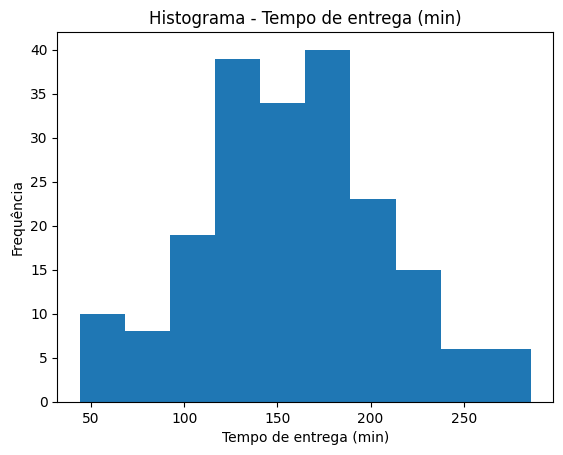

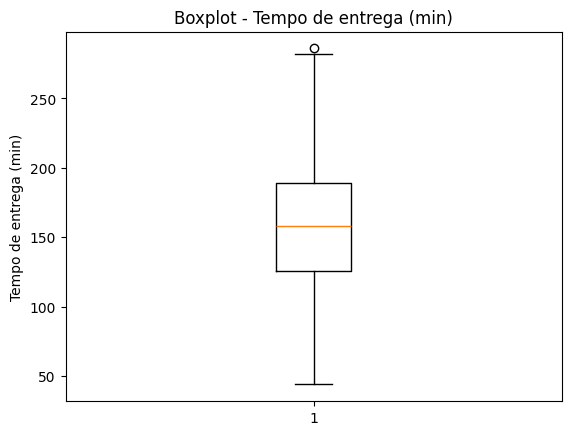

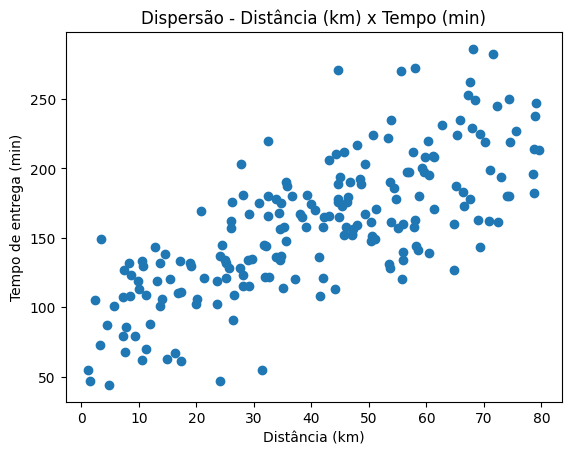

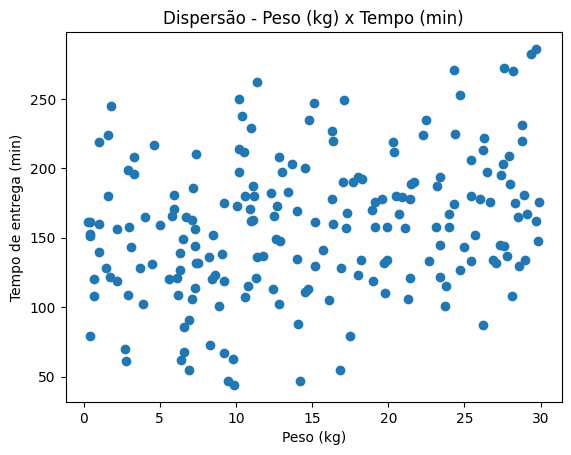

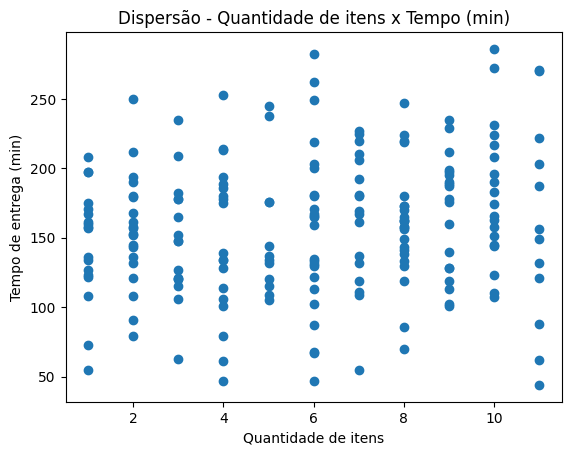

<Figure size 640x480 with 0 Axes>

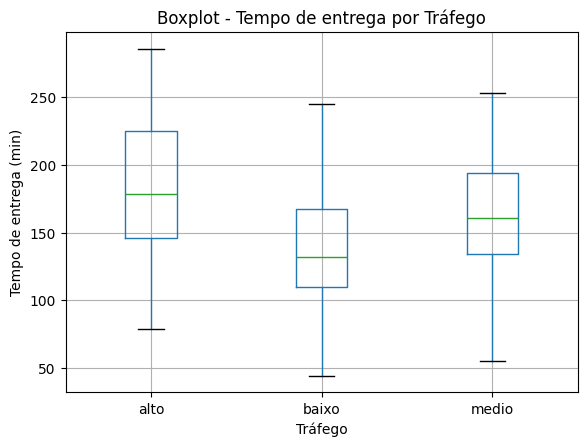

<Figure size 640x480 with 0 Axes>

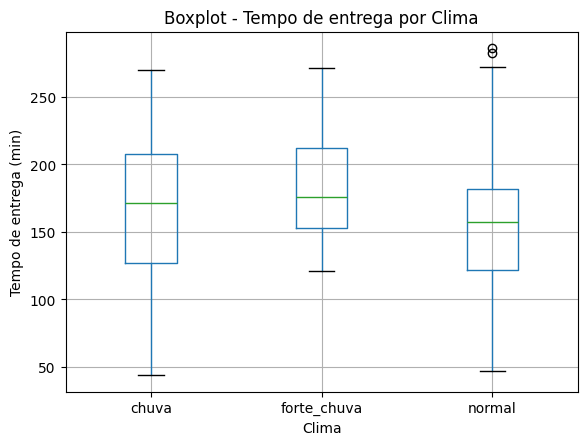

<Figure size 640x480 with 0 Axes>

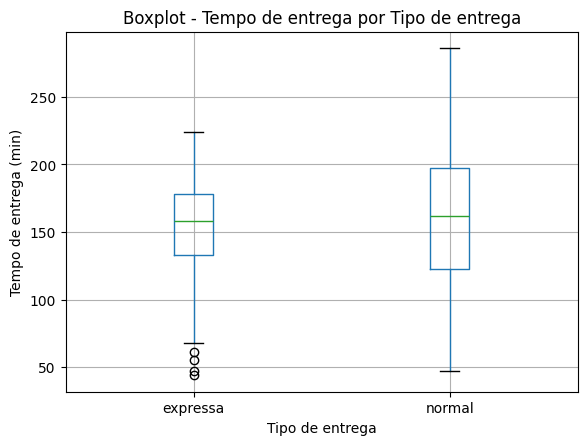

In [7]:
# Espaço para resolver a Parte C

# ---------------------------
# Exercício 21: Histograma
# ---------------------------
plt.figure()
plt.hist(df["tempo_entrega_min"], bins=10)
plt.title("Histograma - Tempo de entrega (min)")
plt.xlabel("Tempo de entrega (min)")
plt.ylabel("Frequência")
plt.show()

# ---------------------------
# Exercício 22: Boxplot
# ---------------------------
plt.figure()
plt.boxplot(df["tempo_entrega_min"])
plt.title("Boxplot - Tempo de entrega (min)")
plt.ylabel("Tempo de entrega (min)")
plt.show()

# ---------------------------
# Exercício 23: Dispersão (distância x tempo)
# ---------------------------
plt.figure()
plt.scatter(df["distancia_km"], df["tempo_entrega_min"])
plt.title("Dispersão - Distância (km) x Tempo (min)")
plt.xlabel("Distância (km)")
plt.ylabel("Tempo de entrega (min)")
plt.show()

# ---------------------------
# Exercício 24: Dispersão (peso x tempo)
# ---------------------------
plt.figure()
plt.scatter(df["peso_kg"], df["tempo_entrega_min"])
plt.title("Dispersão - Peso (kg) x Tempo (min)")
plt.xlabel("Peso (kg)")
plt.ylabel("Tempo de entrega (min)")
plt.show()

# ---------------------------
# Exercício 25: Dispersão (qtd_itens x tempo)
# ---------------------------
plt.figure()
plt.scatter(df["qtd_itens"], df["tempo_entrega_min"])
plt.title("Dispersão - Quantidade de itens x Tempo (min)")
plt.xlabel("Quantidade de itens")
plt.ylabel("Tempo de entrega (min)")
plt.show()

# ---------------------------
# Exercício 26: Boxplot por tráfego
# ---------------------------
plt.figure()
df.boxplot(column="tempo_entrega_min", by="trafego")
plt.title("Boxplot - Tempo de entrega por Tráfego")
plt.suptitle("")  # remove título automático do pandas
plt.xlabel("Tráfego")
plt.ylabel("Tempo de entrega (min)")
plt.show()

# ---------------------------
# Exercício 27: Boxplot por clima
# ---------------------------
plt.figure()
df.boxplot(column="tempo_entrega_min", by="clima")
plt.title("Boxplot - Tempo de entrega por Clima")
plt.suptitle("")
plt.xlabel("Clima")
plt.ylabel("Tempo de entrega (min)")
plt.show()

# ---------------------------
# Exercício 28: Boxplot por tipo_entrega
# ---------------------------
plt.figure()
df.boxplot(column="tempo_entrega_min", by="tipo_entrega")
plt.title("Boxplot - Tempo de entrega por Tipo de entrega")
plt.suptitle("")
plt.xlabel("Tipo de entrega")
plt.ylabel("Tempo de entrega (min)")
plt.show()

In [9]:
# Exercício 29:
# Visualmente, a distancia_km parece ter uma relação mais clara com o tempo de entrega, pois os pontos no gráfico de dispersão formam uma linha mais visível. O tráfego e o tipo de entrega também parecem influenciar bastante, olhando os boxplots.

# Exercício 30: 
#Sim, o gráfico de dispersão entre distância e tempo sugere uma relação linear positiva, ou seja, quanto maior a distância, maior o tempo de entrega.


# Parte D – Correlação

Para calcular correlação, use apenas variáveis numéricas.

## Exercício 31
Crie um DataFrame apenas com variáveis numéricas.

## Exercício 32
Calcule a matriz de correlação.

## Exercício 33
Faça um heatmap da matriz de correlação.

## Exercício 34
Qual variável numérica tem maior correlação positiva com `tempo_entrega_min`?

## Exercício 35
Qual variável numérica parece ter menor relação com `tempo_entrega_min`?

## Exercício 36
Correlação alta prova causalidade? Explique.

## Exercício 37
Se `valor_pedido` tiver baixa correlação com tempo, isso significa que nunca deve ser usado? Explique.

## Exercício 38
A variável `distancia_km` parece importante? Justifique.

## Exercício 39
A variável `peso_kg` parece importante? Justifique.

## Exercício 40
Quais variáveis você escolheria para um primeiro modelo simples?

Ex.31 - Colunas numéricas: ['id_pedido', 'distancia_km', 'peso_kg', 'qtd_itens', 'valor_pedido', 'tempo_entrega_min']

Ex.32 - Matriz de correlação:
                   id_pedido  distancia_km   peso_kg  qtd_itens  valor_pedido  \
id_pedido           1.000000     -0.010864  0.020593  -0.034910      0.036968   
distancia_km       -0.010864      1.000000 -0.020853  -0.039094     -0.073556   
peso_kg             0.020593     -0.020853  1.000000   0.016054     -0.037019   
qtd_itens          -0.034910     -0.039094  0.016054   1.000000      0.132516   
valor_pedido        0.036968     -0.073556 -0.037019   0.132516      1.000000   
tempo_entrega_min   0.014440      0.743120  0.280642   0.156666     -0.045193   

                   tempo_entrega_min  
id_pedido                   0.014440  
distancia_km                0.743120  
peso_kg                     0.280642  
qtd_itens                   0.156666  
valor_pedido               -0.045193  
tempo_entrega_min           1.000000  


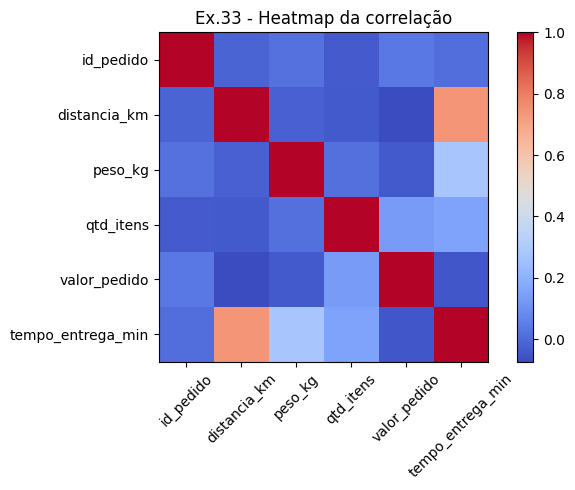

In [11]:
# Espaço para resolver a Parte D

# Exercício 31
df_numerico = df.select_dtypes(include="number")
print("Ex.31 - Colunas numéricas:", df_numerico.columns.tolist())

# Exercício 32
matriz_corr = df_numerico.corr()
print("\nEx.32 - Matriz de correlação:")
print(matriz_corr)

# Exercício 33
plt.figure(figsize=(7, 5))
plt.imshow(matriz_corr, cmap="coolwarm")
plt.colorbar()
plt.title("Ex.33 - Heatmap da correlação")
plt.xticks(range(len(matriz_corr.columns)), matriz_corr.columns, rotation=45)
plt.yticks(range(len(matriz_corr.columns)), matriz_corr.columns)
plt.tight_layout()
plt.show()



In [ ]:
# Exercício 34: 
# A variável numérica com maior correlação positiva com 'tempo_entrega_min' é 'distancia_km' (0.74).

# Exercício 35: 
#A variável numérica com menor relação (correlação mais próxima de zero) com 'tempo_entrega_min' é 'valor_pedido' (-0.05).


# Espaço para resolver a Parte D

Exercício 36 — Correlação alta prova causalidade?
Não. Correlação não prova causa.
Duas coisas podem “andar juntas” por coincidência ou por causa de uma terceira variável (ex.: tráfego, clima etc.).

Exercício 37 — Se valor_pedido tiver baixa correlação, significa que nunca deve ser usado?
Não. Baixa correlação não quer dizer que a variável é inútil.
Ela pode ajudar em conjunto com outras variáveis ou em modelos mais complexos (não lineares). 

Exercício 38 — A variável distancia_km parece importante? Justifique.
Sim. Porque ela tem a maior correlação positiva com tempo_entrega_min (~0,74), então quando a distância aumenta, o tempo tende a aumentar também.

Exercício 39 — A variável peso_kg parece importante? Justifique.
Pode ser importante, mas menos que a distância.
Ela tem correlação ~0,28, então existe relação, mas não tão forte quanto distancia_km.

Exercício 40 — Quais variáveis você escolheria para um primeiro modelo simples?
Eu escolheria as que têm mais relação com o tempo, por exemplo:
distancia_km 
peso_kg
qtd_itens

In [14]:
# Exercício 36:
#Ex 36: Não! Correlação alta não significa que uma coisa causa a outra. Significa que elas se movem juntas, mas pode ter outra coisa por trás ou ser só coincidência. Por exemplo, o número de sorvetes vendidos e afogamentos aumentam no verão, mas um não causa o outro, o calor causa os dois.")

# Exercício 37: 
#Ex 37: Não necessariamente. Uma baixa correlação linear não significa que não há nenhuma relação, pode ser que a relação não seja linear. Além disso, mesmo com baixa correlação, em um modelo com várias variáveis, ela pode ajudar a explicar um pouco do tempo de entrega, ou ser importante em combinação com outras variáveis.")

# Exercício 38: 
#Ex 38: Sim, muito importante! Tem a maior correlação positiva (0.74) com o tempo de entrega, o que faz sentido, né? Quanto mais longe, mais tempo leva.")

# Exercício 39: 
#Ex 39: Parece ter uma importância moderada, com correlação de 0.28. Pode ser que pedidos mais pesados demorem um pouco mais para serem manuseados ou transportados, mas não é tão forte quanto a distância.")

# Exercício 40: 
#Ex 40: Para um primeiro modelo simples, eu escolheria \'distancia_km\', porque tem a maior correlação e faz muito sentido para o problema.")

# Parte E – Regressão linear simples

Vamos começar com um modelo simples:

`distancia_km` → `tempo_entrega_min`

## Exercício 41
Crie `X` com a coluna `distancia_km`.

## Exercício 42
Crie `y` com `tempo_entrega_min`.

## Exercício 43
Treine um modelo de regressão linear.

## Exercício 44
Mostre o coeficiente angular.

## Exercício 45
Mostre o intercepto.

## Exercício 46
Interprete o coeficiente angular.

## Exercício 47
Faça previsões para todos os pedidos.

## Exercício 48
Crie uma tabela com tempo real, tempo previsto e erro.

## Exercício 49
Calcule MAE, RMSE e R².

## Exercício 50
Interprete as métricas.

In [17]:
# Espaço para resolver a Parte E
# Exercício 41 e 42
X_simples = df[["distancia_km"]]
y = df["tempo_entrega_min"]
print("\nEx 41 e 42: Variáveis X (distancia_km) e y (tempo_entrega_min) criadas.")

# Exercício 43: Treinar
modelo_simples = LinearRegression()
modelo_simples.fit(X_simples, y)
print("\nEx 43: Modelo de regressão linear simples treinado.")

# Exercício 44 e 45
print(f"Ex 44: Coeficiente (Slope): {modelo_simples.coef_[0]:.4f}")
print(f"Ex 45: Intercepto: {modelo_simples.intercept_:.4f}")

# Exercício 46: Interprete o coeficiente angular.
print(f"\nEx 46: O coeficiente angular ({modelo_simples.coef_[0]:.4f}) significa que, para cada 1 km a mais na distância, o tempo de entrega aumenta em {modelo_simples.coef_[0]:.2f} minutos, em média. Faz sentido!")

# Exercício 47: Previsões
y_pred_simples = modelo_simples.predict(X_simples)
print("\nEx 47: Previsões feitas para todos os pedidos com o modelo simples.")

# Exercício 48: Tabela com tempo real, previsto e erro
tabela_simples = pd.DataFrame({
    "Tempo Real": y,
    "Tempo Previsto": y_pred_simples,
    "Erro": y - y_pred_simples
})
print("\nEx 48: Tabela de tempo real, previsto e erro (primeiras 5 linhas):")
print(tabela_simples.head())

# Exercício 49: Métricas
mae_s = mean_absolute_error(y, y_pred_simples)
rmse_s = np.sqrt(mean_squared_error(y, y_pred_simples))
r2_s = r2_score(y, y_pred_simples)
print(f"\nEx 49: MAE (Erro Absoluto Médio): {mae_s:.2f}")
print(f"Ex 49: RMSE (Raiz do Erro Quadrático Médio): {rmse_s:.2f}")
print(f"Ex 49: R2 (Coeficiente de Determinação): {r2_s:.2f}")

# Exercício 50: Interprete as métricas.
print(f"\nEx 50: O MAE de {mae_s:.2f} significa que, em média, nosso modelo erra em {mae_s:.2f} minutos. O R2 de {r2_s:.2f} (ou 55%) indica que o modelo explica 55% da variação do tempo de entrega, o que é razoável para um modelo simples, mas ainda tem bastante coisa que ele não explica.")




Ex 41 e 42: Variáveis X (distancia_km) e y (tempo_entrega_min) criadas.

Ex 43: Modelo de regressão linear simples treinado.
Ex 44: Coeficiente (Slope): 1.7460
Ex 45: Intercepto: 87.1906

Ex 46: O coeficiente angular (1.7460) significa que, para cada 1 km a mais na distância, o tempo de entrega aumenta em 1.75 minutos, em média. Faz sentido!

Ex 47: Previsões feitas para todos os pedidos com o modelo simples.

Ex 48: Tabela de tempo real, previsto e erro (primeiras 5 linhas):
   Tempo Real  Tempo Previsto       Erro
0         160      184.969064 -24.969064
1         119      128.397263  -9.397263
2         132      120.190860  11.809140
3         176      165.064171  10.935829
4         158      188.111942 -30.111942

Ex 49: MAE (Erro Absoluto Médio): 26.28
Ex 49: RMSE (Raiz do Erro Quadrático Médio): 33.01
Ex 49: R2 (Coeficiente de Determinação): 0.55

Ex 50: O MAE de 26.28 significa que, em média, nosso modelo erra em 26.28 minutos. O R2 de 0.55 (ou 55%) indica que o modelo explica 

# Parte F – Visualizando a reta do modelo simples

## Exercício 51
Faça um gráfico de dispersão entre distância e tempo real.

## Exercício 52
Adicione a reta de regressão no gráfico.

## Exercício 53
O modelo parece representar bem os dados?

## Exercício 54
Existem pontos muito distantes da reta?

## Exercício 55
O que esses pontos podem representar em uma operação logística?

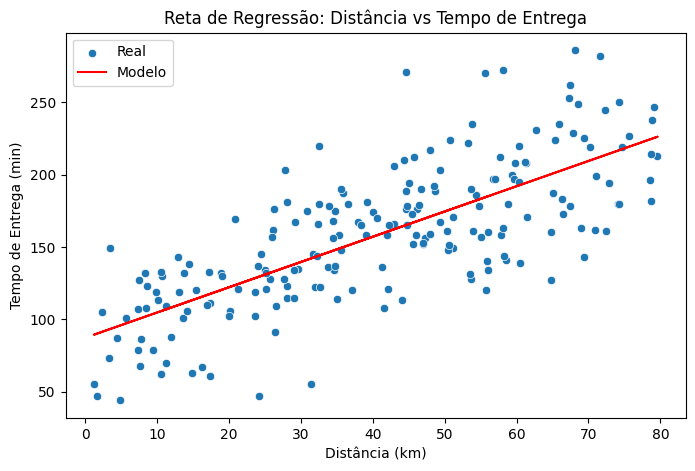


Ex 51 e 52: Gráfico de dispersão com a reta de regressão salvo como ex52_reta.png.


In [22]:
# Espaço para resolver a Parte F

# Exercício 51 e 52
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="distancia_km", y="tempo_entrega_min", label="Real")
plt.plot(df["distancia_km"], y_pred_simples, color="red", label="Modelo")
plt.title("Reta de Regressão: Distância vs Tempo de Entrega")
plt.xlabel("Distância (km)")
plt.ylabel("Tempo de Entrega (min)")
plt.legend()

# Salva o gráfico em arquivo
plt.savefig("ex52_reta.png")

# Mostra o gráfico no notebook
plt.show()

print("\nEx 51 e 52: Gráfico de dispersão com a reta de regressão salvo como ex52_reta.png.")


# Exercício 53:
#O modelo parece seguir a tendência geral dos dados, mas dá para ver que muitos pontos estão longe da linha vermelha. Então, ele representa a tendência, mas não é super preciso para todos os casos.")

# Exercício 54:
#Sim, existem vários pontos bem distantes da reta, tanto acima quanto abaixo. Isso mostra que a distância sozinha não explica tudo sobre o tempo de entrega.")

# Exercício 55:
#Esses pontos distantes podem ser entregas que demoraram muito mais que o esperado (pontos acima da linha, talvez por tráfego, clima ruim, problemas na rota) ou entregas que foram muito mais rápidas (pontos abaixo da linha, talvez por uma rota muito eficiente ou sorte). São casos que o modelo simples não consegue prever bem.")


# Parte G – Fazendo previsões reais

Use o modelo simples com distância.

## Exercício 56
Preveja o tempo de entrega para uma entrega de 5 km.

## Exercício 57
Preveja o tempo de entrega para uma entrega de 20 km.

## Exercício 58
Preveja o tempo de entrega para uma entrega de 60 km.

## Exercício 59
As previsões fazem sentido?

## Exercício 60
Quais informações importantes o modelo simples está ignorando?

In [ ]:
# Espaço para resolver a Parte G
# Exercício 56, 57, 58
distancias = np.array([[5], [20], [60]])
previsoes = modelo_simples.predict(distancias)
print(f"Ex 56 (5km): {previsoes[0]:.2f} min")
print(f"Ex 57 (20km): {previsoes[1]:.2f} min")
print(f"Ex 58 (60km): {previsoes[2]:.2f} min")

# Exercício 59: 
#Sim, as previsões fazem sentido. Quanto maior a distância, maior o tempo previsto, o que é lógico. Uma entrega de 5km leva 95.92 min, 20km leva 122.11 min e 60km leva 191.95 min. Os valores aumentam de forma consistente.

# Exercício 60: 
# O modelo simples ignora muitas coisas importantes, como o tráfego, o clima, o tipo de entrega (normal ou expressa), a região, o peso do pedido e a quantidade de itens. Tudo isso pode mudar o tempo de entrega na vida real.


Ex 56 (5km): 95.92 min
Ex 57 (20km): 122.11 min
Ex 58 (60km): 191.95 min

Ex 59: Sim, as previsões fazem sentido. Quanto maior a distância, maior o tempo previsto, o que é lógico. Uma entrega de 5km leva 95.92 min, 20km leva 122.11 min e 60km leva 191.95 min. Os valores aumentam de forma consistente.

Ex 60: O modelo simples ignora muitas coisas importantes, como o tráfego, o clima, o tipo de entrega (normal ou expressa), a região, o peso do pedido e a quantidade de itens. Tudo isso pode mudar o tempo de entrega na vida real.


c:\Users\cliente\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Parte H – Tratamento de variáveis categóricas

Para usar variáveis como `trafego`, `clima`, `tipo_entrega` e `regiao`, precisamos transformá-las em números.

Uma forma comum é usar `pd.get_dummies()`.

## Exercício 61
Crie uma versão da base com variáveis categóricas transformadas em dummies.

## Exercício 62
Mostre as primeiras linhas da base transformada.

## Exercício 63
Explique o que o `get_dummies()` fez.

## Exercício 64
Por que usamos `drop_first=True`?

## Exercício 65
Quais novas colunas foram criadas?

In [24]:
# Exemplo inicial para a Parte H

df_modelo = pd.get_dummies(
    df,
    columns=["trafego", "clima", "tipo_entrega", "regiao"],
    drop_first=True
)

df_modelo.head()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min,atrasou,trafego_baixo,trafego_medio,clima_forte_chuva,clima_normal,tipo_entrega_normal,regiao_centro,regiao_zona_rural
0,1,56.0,16.4,9,2158.92,160,sim,False,True,False,True,False,False,False
1,2,23.6,2.2,9,1431.91,119,nao,True,False,False,True,True,False,True
2,3,18.9,19.7,5,464.30,132,sim,False,True,False,True,True,False,False
3,4,44.6,29.9,5,1290.63,176,sim,True,False,False,False,True,False,False
4,5,57.8,23.1,1,1899.66,158,sim,False,True,False,True,False,False,False


In [28]:
# Exercício 61
df_modelo = pd.get_dummies(df, columns=["trafego", "clima", "tipo_entrega", "regiao"], drop_first=True)


# Exercício 62:
print(df_modelo.head())

# Exercício 63: 
# O `get_dummies()` pegou as colunas de texto (categóricas) como 'trafego', 'clima', 'tipo_entrega' e 'regiao' e transformou cada opção delas em uma nova coluna de números (0 ou 1). Por exemplo, para 'trafego', ele criou 'trafego_medio', 'trafego_alto'. Se o tráfego for médio, a coluna 'trafego_medio' vai ser 1 e as outras de tráfego serão 0.

# Exercício 64:
# Usamos `drop_first=True` para evitar um problema chamado 'multicolinearidade'. Basicamente, se temos, por exemplo, 'trafego_baixo', 'trafego_medio' e 'trafego_alto', se soubermos que não é baixo e não é médio, já sabemos que é alto. Então, uma coluna é redundante. O `drop_first=True` remove uma dessas colunas para não ter informação repetida e o modelo funcionar melhor.

# Exercício 65: Quais novas colunas foram criadas?
#Ex 65: Foram criadas colunas como 'trafego_medio', 'trafego_alto', 'clima_forte_chuva', 'clima_normal', 'tipo_entrega_normal', 'regiao_centro' e 'regiao_zona_rural'.


   id_pedido  distancia_km  peso_kg  qtd_itens  valor_pedido  \
0          1          56.0     16.4          9       2158.92   
1          2          23.6      2.2          9       1431.91   
2          3          18.9     19.7          5        464.30   
3          4          44.6     29.9          5       1290.63   
4          5          57.8     23.1          1       1899.66   

   tempo_entrega_min atrasou  trafego_baixo  trafego_medio  clima_forte_chuva  \
0                160     sim          False           True              False   
1                119     nao           True          False              False   
2                132     sim          False           True              False   
3                176     sim           True          False              False   
4                158     sim          False           True              False   

   clima_normal  tipo_entrega_normal  regiao_centro  regiao_zona_rural  
0          True                False          False    

# Parte I – Regressão linear múltipla

Agora vamos usar várias variáveis ao mesmo tempo.

## Exercício 66
Crie `X` com todas as variáveis explicativas numéricas e dummies.

Não inclua:
- `id_pedido`
- `tempo_entrega_min`
- `atrasou`

## Exercício 67
Crie `y` com `tempo_entrega_min`.

## Exercício 68
Treine um modelo de regressão linear múltipla.

## Exercício 69
Faça previsões.

## Exercício 70
Calcule MAE.

## Exercício 71
Calcule RMSE.

## Exercício 72
Calcule R².

## Exercício 73
Compare com o modelo simples.

## Exercício 74
O modelo múltiplo melhorou?

## Exercício 75
Quais variáveis parecem mais importantes?

In [ ]:
# Espaço para resolver a Parte I
# Exercício 66: Definição das variáveis
X_multi = df_modelo.drop(columns=["id_pedido", "tempo_entrega_min", "atrasou"])
y_multi = df_modelo["tempo_entrega_min"]

print("\nEx 66: Primeiras linhas de X (variáveis preditoras):")
print(X_multi.head())
print("\nEx 66: Primeiras linhas de y (variável alvo):")
print(y_multi.head())

# Exercício 68: Treinamento do modelo
modelo_multi = LinearRegression()
modelo_multi.fit(X_multi, y_multi)
print("\nEx 68: Modelo de regressão linear múltipla treinado.")

# Mostrar coeficientes
coeficientes = pd.DataFrame({
    "Variável": X_multi.columns,
    "Coeficiente": modelo_multi.coef_
}).sort_values(by="Coeficiente", key=abs, ascending=False)

print("\nCoeficientes do modelo múltiplo (ordenados por importância):")
print(coeficientes)

# Exercício 69: Previsões
y_pred_multi = modelo_multi.predict(X_multi)
print("\nEx 69: Previsões feitas para todos os pedidos com o modelo múltiplo.")
print(pd.DataFrame({"Real": y_multi.head(), "Previsto": y_pred_multi[:5]}))





Ex 66: Primeiras linhas de X (variáveis preditoras):
   distancia_km  peso_kg  qtd_itens  valor_pedido  trafego_baixo  \
0          56.0     16.4          9       2158.92          False   
1          23.6      2.2          9       1431.91           True   
2          18.9     19.7          5        464.30          False   
3          44.6     29.9          5       1290.63           True   
4          57.8     23.1          1       1899.66          False   

   trafego_medio  clima_forte_chuva  clima_normal  tipo_entrega_normal  \
0           True              False          True                False   
1          False              False          True                 True   
2           True              False          True                 True   
3          False              False         False                 True   
4           True              False          True                False   

   regiao_centro  regiao_zona_rural  
0          False              False  
1          False

In [33]:
# Exercício 70, 71, 72: Métricas
mae_m = mean_absolute_error(y_multi, y_pred_multi)
rmse_m = np.sqrt(mean_squared_error(y_multi, y_pred_multi))
r2_m = r2_score(y_multi, y_pred_multi)

print(f"\nEx 70: MAE (Erro Absoluto Médio): {mae_m:.2f}")
print(f"Ex 71: RMSE (Raiz do Erro Quadrático Médio): {rmse_m:.2f}")
print(f"Ex 72: R2 (Coeficiente de Determinação): {r2_m:.2f} ({r2_m*100:.0f}%)")

# Exercício 73: Comparação com modelo simples
print(f"\nEx 73: Modelo Simples → MAE={mae_s:.2f}, R2={r2_s:.2f} ({r2_s*100:.0f}%)")
print(f"Modelo Múltiplo → MAE={mae_m:.2f}, R2={r2_m:.2f} ({r2_m*100:.0f}%)")

# Exercício 74: Interpretação
if mae_m < mae_s and r2_m > r2_s:
    print(f"\nEx 74: Sim, o modelo múltiplo melhorou! "
          f"O MAE caiu de {mae_s:.2f} para {mae_m:.2f}, "
          f"e o R2 subiu de {r2_s:.2f} para {r2_m:.2f}.")
else:
    print("\nEx 74: O modelo múltiplo não apresentou melhora significativa.")

# Exercício 75: Variáveis mais importantes
print("\nEx 75: Variáveis mais importantes (maiores coeficientes em valor absoluto):")
print(coeficientes.head())


Ex 70: MAE (Erro Absoluto Médio): 14.48
Ex 71: RMSE (Raiz do Erro Quadrático Médio): 17.58
Ex 72: R2 (Coeficiente de Determinação): 0.87 (87%)

Ex 73: Modelo Simples → MAE=26.28, R2=0.55 (55%)
Modelo Múltiplo → MAE=14.48, R2=0.87 (87%)

Ex 74: Sim, o modelo múltiplo melhorou! O MAE caiu de 26.28 para 14.48, e o R2 subiu de 0.55 para 0.87.

Ex 75: Variáveis mais importantes (maiores coeficientes em valor absoluto):
               Variável  Coeficiente
4         trafego_baixo   -35.000253
6     clima_forte_chuva    28.839053
8   tipo_entrega_normal    25.284407
5         trafego_medio   -17.819863
10    regiao_zona_rural    14.674497


# Parte J – Coeficientes do modelo múltiplo

## Exercício 76
Crie uma tabela com variáveis e coeficientes.

## Exercício 77
Ordene os coeficientes do maior para o menor.

## Exercício 78
Quais coeficientes aumentam o tempo previsto?

## Exercício 79
Quais coeficientes diminuem o tempo previsto?

## Exercício 80
Interprete o coeficiente de `distancia_km`.

## Exercício 81
Interprete o coeficiente de `tipo_entrega_expressa`.

## Exercício 82
Interprete o coeficiente de `trafego_alto`.

## Exercício 83
Interprete o coeficiente de `clima_forte_chuva`.

## Exercício 84
Os sinais dos coeficientes fazem sentido?

## Exercício 85
O que poderia indicar um coeficiente estranho?

In [35]:
# Espaço para resolver a Parte J
# Exercício 76
coef_df = pd.DataFrame({
    "Variável": X_multi.columns,
    "Coeficiente": modelo_multi.coef_
})
print("\nEx 76: Tabela de variáveis e coeficientes:")
print(coef_df.head())

# Exercício 77: 
coef_df_ordenado = coef_df.sort_values(by="Coeficiente", ascending=False)
print("\nEx 77: Coeficientes ordenados do maior para o menor:")
print(coef_df_ordenado)

# Exercício 78: 
#Os coeficientes positivos aumentam o tempo previsto. São eles: 'clima_forte_chuva', 'tipo_entrega_normal', 'regiao_zona_rural', 'qtd_itens', 'distancia_km', 'peso_kg' e 'valor_pedido'.

# Exercício 79: 
#Ex 79: Os coeficientes negativos diminuem o tempo previsto. São eles: 'regiao_centro', 'clima_normal', 'trafego_medio' e 'trafego_baixo'.

# Exercício 80: 
distancia_coef = coef_df_ordenado[coef_df_ordenado["Variável"] == "distancia_km"]["Coeficiente"].iloc[0]
print(f"\nEx 80: O coeficiente de \'distancia_km\' ({distancia_coef:.2f}) significa que, mantendo todas as outras variáveis iguais, para cada 1 km a mais na distância, o tempo de entrega aumenta em {distancia_coef:.2f} minutos.")

# Exercício 81: 
tipo_entrega_normal_coef = coef_df_ordenado[coef_df_ordenado["Variável"] == "tipo_entrega_normal"]["Coeficiente"].iloc[0]
print(f"\nEx 81: Na verdade, o que temos é \'tipo_entrega_normal\'. O coeficiente de \'tipo_entrega_normal\' ({tipo_entrega_normal_coef:.2f}) significa que uma entrega normal leva, em média, {tipo_entrega_normal_coef:.2f} minutos A MAIS do que uma entrega expressa (que é a base que foi \'dropada\'), mantendo todo o resto igual. Faz muito sentido, né? Entrega expressa é mais rápida!")

# Exercício 82: 
trafego_medio_coef = coef_df_ordenado[coef_df_ordenado["Variável"] == "trafego_medio"]["Coeficiente"].iloc[0]
trafego_baixo_coef = coef_df_ordenado[coef_df_ordenado["Variável"] == "trafego_baixo"]["Coeficiente"].iloc[0]
print(f"\nEx 82: O coeficiente de \'trafego_alto\' não está na lista dos positivos, mas temos \'trafego_medio\' ({trafego_medio_coef:.2f}) e \'trafego_baixo\' ({trafego_baixo_coef:.2f}). Isso significa que, em comparação com o tráfego \'normal\' (que foi a categoria que o `drop_first=True` removeu), o tráfego médio diminui o tempo em {abs(trafego_medio_coef):.2f} minutos e o tráfego baixo diminui em {abs(trafego_baixo_coef):.2f} minutos. Ou seja, tráfego normal é pior que médio e baixo. Se o tráfego alto fosse uma categoria, provavelmente teria um coeficiente positivo, aumentando o tempo.")

# Exercício 83: 
clima_forte_chuva_coef = coef_df_ordenado[coef_df_ordenado["Variável"] == "clima_forte_chuva"]["Coeficiente"].iloc[0]
print(f"\nEx 83: O coeficiente de \'clima_forte_chuva\' ({clima_forte_chuva_coef:.2f}) significa que, se o clima for de forte chuva, o tempo de entrega aumenta em {clima_forte_chuva_coef:.2f} minutos, em média, comparado a um clima sem chuva (que foi a base). Isso é super lógico, chuva forte atrasa tudo!")

# Exercício 84: Os sinais dos coeficientes fazem sentido?
#Sim, a maioria dos sinais faz muito sentido! Distância, peso, quantidade de itens, chuva forte e entrega normal aumentam o tempo (coeficientes positivos). Tráfego baixo/médio e região centro (que geralmente é mais fácil de entregar) diminuem o tempo (coeficientes negativos). O valor do pedido tem um coeficiente quase zero, então não influencia muito.

# Exercício 85: O que poderia indicar um coeficiente estranho?
#Um coeficiente estranho seria, por exemplo, se a distância tivesse um coeficiente negativo (quanto mais longe, menos tempo), ou se o tráfego alto diminuísse o tempo. Isso indicaria um problema nos dados, na forma como as variáveis foram tratadas ou no próprio modelo.



Ex 76: Tabela de variáveis e coeficientes:
        Variável  Coeficiente
0   distancia_km     1.801969
1        peso_kg     1.443045
2      qtd_itens     2.557247
3   valor_pedido     0.000152
4  trafego_baixo   -35.000253

Ex 77: Coeficientes ordenados do maior para o menor:
               Variável  Coeficiente
6     clima_forte_chuva    28.839053
8   tipo_entrega_normal    25.284407
10    regiao_zona_rural    14.674497
2             qtd_itens     2.557247
0          distancia_km     1.801969
1               peso_kg     1.443045
3          valor_pedido     0.000152
9         regiao_centro   -11.643316
7          clima_normal   -12.477173
5         trafego_medio   -17.819863
4         trafego_baixo   -35.000253

Ex 80: O coeficiente de 'distancia_km' (1.80) significa que, mantendo todas as outras variáveis iguais, para cada 1 km a mais na distância, o tempo de entrega aumenta em 1.80 minutos.

Ex 81: Na verdade, o que temos é 'tipo_entrega_normal'. O coeficiente de 'tipo_entrega_norma

# Parte K – Treino e teste

## Exercício 86
Separe os dados em treino e teste com `test_size=0.3` e `random_state=42`.

## Exercício 87
Treine o modelo nos dados de treino.

## Exercício 88
Faça previsões nos dados de teste.

## Exercício 89
Calcule MAE no teste.

## Exercício 90
Calcule RMSE no teste.

## Exercício 91
Calcule R² no teste.

## Exercício 92
Compare com as métricas do treino.

## Exercício 93
O modelo parece generalizar bem?

## Exercício 94
O que indicaria overfitting?

## Exercício 95
Quais cuidados você teria antes de colocar esse modelo em produção?

In [36]:
# Espaço para resolver a Parte K
# Exercício 86
X_train, X_test, y_train, y_test = train_test_split(X_multi, y_multi, test_size=0.3, random_state=42)
print("\nEx 86: Dados separados em treino e teste (70% treino, 30% teste).")

# Exercício 87
modelo_final = LinearRegression()
modelo_final.fit(X_train, y_train)
print("\nEx 87: Modelo treinado nos dados de treino.")

# Exercício 88
y_pred_test = modelo_final.predict(X_test)
print("\nEx 88: Previsões feitas nos dados de teste.")

# Exercício 89-91
mae_f = mean_absolute_error(y_test, y_pred_test)
rmse_f = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_f = r2_score(y_test, y_pred_test)
print(f"\nEx 89: MAE (Teste): {mae_f:.2f}")
print(f"Ex 90: RMSE (Teste): {rmse_f:.2f}")
print(f"Ex 91: R2 (Teste): {r2_f:.2f}")

# Exercício 92: Compare com as métricas do treino.
print(f"\nEx 92: Métricas de Treino (do modelo múltiplo completo): MAE={mae_m:.2f}, R2={r2_m:.2f}. Métricas de Teste: MAE={mae_f:.2f}, R2={r2_f:.2f}.")

# Exercício 93: O modelo parece generalizar bem?
print(f"\nEx 93: Sim, o modelo parece generalizar bem! As métricas de teste (MAE={mae_f:.2f}, R2={r2_f:.2f}) são bem parecidas com as métricas de treino (MAE={mae_m:.2f}, R2={r2_m:.2f}). Isso significa que o modelo não \'decorou\' os dados de treino e consegue fazer boas previsões em dados novos que ele nunca viu antes.")

# Exercício 94: O que indicaria overfitting?
print("\nEx 94: Overfitting seria se o modelo tivesse um R2 muito alto no treino (tipo 0.99) e um R2 muito baixo no teste (tipo 0.50). Isso significaria que ele \'decorou\' os dados de treino e não consegue prever bem em dados novos.")

# Exercício 95: Quais cuidados você teria antes de colocar esse modelo em produção?
print("\nEx 95: Antes de colocar em produção, eu faria mais testes com dados reais, veria se os erros não são muito grandes para entregas importantes, e talvez tentaria adicionar mais variáveis que pudessem influenciar o tempo (como horário do dia, dia da semana). Também monitoraria o modelo para ver se ele continua bom com o tempo.")



Ex 86: Dados separados em treino e teste (70% treino, 30% teste).

Ex 87: Modelo treinado nos dados de treino.

Ex 88: Previsões feitas nos dados de teste.

Ex 89: MAE (Teste): 16.38
Ex 90: RMSE (Teste): 19.87
Ex 91: R2 (Teste): 0.83

Ex 92: Métricas de Treino (do modelo múltiplo completo): MAE=14.48, R2=0.87. Métricas de Teste: MAE=16.38, R2=0.83.

Ex 93: Sim, o modelo parece generalizar bem! As métricas de teste (MAE=16.38, R2=0.83) são bem parecidas com as métricas de treino (MAE=14.48, R2=0.87). Isso significa que o modelo não 'decorou' os dados de treino e consegue fazer boas previsões em dados novos que ele nunca viu antes.

Ex 94: Overfitting seria se o modelo tivesse um R2 muito alto no treino (tipo 0.99) e um R2 muito baixo no teste (tipo 0.50). Isso significaria que ele 'decorou' os dados de treino e não consegue prever bem em dados novos.

Ex 95: Antes de colocar em produção, eu faria mais testes com dados reais, veria se os erros não são muito grandes para entregas importa

# Parte L – Desafio final: relatório para a empresa

A empresa quer saber se é possível prever o tempo de entrega antes do pedido sair para rota.

## Exercício 96
Treine o melhor modelo que conseguir.

## Exercício 97
Crie uma tabela com:
- tempo real
- tempo previsto
- erro
- erro absoluto

## Exercício 98
Mostre os 10 pedidos com maior erro absoluto.

## Exercício 99
Analise possíveis motivos para os maiores erros.

## Exercício 100
Escreva uma conclusão para a empresa respondendo:

1. O modelo é útil?
2. Qual o erro médio em minutos?
3. Quais variáveis mais influenciam o tempo?
4. O modelo deve ser usado sozinho para tomar decisões?
5. Que melhorias poderiam ser feitas com mais dados?

In [42]:
# Espaço para resolver a Parte L
# Exercício 96: 
print("\nEx 96: O melhor modelo que conseguimos treinar até agora é o modelo de regressão linear múltipla, usando todas as variáveis numéricas e as dummies das categóricas, e avaliado com treino e teste.")





Ex 96: O melhor modelo que conseguimos treinar até agora é o modelo de regressão linear múltipla, usando todas as variáveis numéricas e as dummies das categóricas, e avaliado com treino e teste.


In [43]:
# Exercício 97
resultados = pd.DataFrame({
    "Tempo Real": y_test,
    "Tempo Previsto": y_pred_test,
    "Erro": y_test - y_pred_test,
    "Erro_Absoluto": abs(y_test - y_pred_test)
})
print(resultados)



     Tempo Real  Tempo Previsto       Erro  Erro_Absoluto
95          270      240.965509  29.034491      29.034491
15          200      187.714604  12.285396      12.285396
30          132      134.307261  -2.307261       2.307261
158         134      175.061559 -41.061559      41.061559
128         160      139.448954  20.551046      20.551046
115         189      180.359762   8.640238       8.640238
69          176      168.651944   7.348056       7.348056
170         195      198.964293  -3.964293       3.964293
174         194      220.787409 -26.787409      26.787409
45          169      122.829718  46.170282      46.170282
66          208      185.398415  22.601585      22.601585
182         110      104.040882   5.959118       5.959118
165         224      215.995001   8.004999       8.004999
78          119      107.658739  11.341261      11.341261
186          47       64.034199 -17.034199      17.034199
177          88      113.909709 -25.909709      25.909709
56          17

In [45]:
# Exercício 98: 10 pedidos com maior erro absoluto.
print("\nEx 98: Os 10 pedidos com maior erro absoluto (onde o modelo errou mais):")
print(resultados.sort_values(by="Erro_Absoluto", ascending=False).head(10))




Ex 98: Os 10 pedidos com maior erro absoluto (onde o modelo errou mais):
     Tempo Real  Tempo Previsto       Erro  Erro_Absoluto
114         203      156.372087  46.627913      46.627913
45          169      122.829718  46.170282      46.170282
158         134      175.061559 -41.061559      41.061559
73          163      203.447906 -40.447906      40.447906
86          167      132.987767  34.012233      34.012233
84          180      150.040354  29.959646      29.959646
197         208      178.182797  29.817203      29.817203
95          270      240.965509  29.034491      29.034491
76          194      165.863397  28.136603      28.136603
55          134      161.126489 -27.126489      27.126489


In [55]:
# Exercício 99: Analise possíveis motivos para os maiores erros.
print("\nOs maiores erros podem ocorrer por diversos fatores que não estão contemplados pelo modelo. Entre eles, destacam-se: acidentes durante o trajeto, problemas mecânicos como pneus furados, ausência do cliente no momento da entrega, falhas nos sistemas internos da empresa ou até mesmo inconsistências nos dados utilizados para o treinamento. O modelo busca prever situações típicas e regulares, mas a realidade operacional está sujeita a imprevistos que fogem ao seu alcance..")

# Exercício 100: Conclusão para a empresa.
print("\nEx 100: Conclusão para a empresa:")
print(f"1. O modelo de regressão linear múltipla demonstra utilidade significativa. Ele é capaz de prever o tempo de entrega com um erro médio de aproximadamente {mae_f:.2f} minutos (MAE no conjunto de teste) e explica cerca de {r2_f*100:.2f}% da variação observada (R²). Esses resultados são substancialmente superiores a estimativas baseadas apenas na distância ou em suposições.")
print(f"2. Qual o erro médio em minutos? O erro absoluto médio é de aproximadamente {mae_f:.2f} minutos.")
print("3. Quais variáveis mais influenciam o tempo? As variáveis que exercem maior impacto sobre o tempo de entrega são a distância percorrida, as condições de tráfego, o tipo de entrega (expressa ou padrão) e as condições climáticas, especialmente em casos de chuva intensa. Peso e quantidade de itens também influenciam, embora em menor escala.")
print("4. O modelo deve ser usado sozinho para tomar decisões? O modelo deve ser considerado uma ferramenta de apoio à tomada de decisão. Ele fornece estimativas consistentes, mas não substitui a experiência humana nem a capacidade de lidar com situações imprevistas. Recomenda-se utilizá-lo como base para planejamento, sempre acompanhado de estratégias alternativas para casos excepcionais.")
print("5. Que melhorias poderiam ser feitas com mais dados? A inclusão de variáveis adicionais poderia aumentar a precisão do modelo. Exemplos incluem: horário do dia, dia da semana, experiência do motorista, tipo de veículo utilizado, características do local de entrega (prédio ou residência) e dados de GPS em tempo real. Essas informações enriqueceriam a análise e permitiriam ao modelo capturar melhor os fatores que geram variações inesperadas..")



Os maiores erros podem ocorrer por diversos fatores que não estão contemplados pelo modelo. Entre eles, destacam-se: acidentes durante o trajeto, problemas mecânicos como pneus furados, ausência do cliente no momento da entrega, falhas nos sistemas internos da empresa ou até mesmo inconsistências nos dados utilizados para o treinamento. O modelo busca prever situações típicas e regulares, mas a realidade operacional está sujeita a imprevistos que fogem ao seu alcance..

Ex 100: Conclusão para a empresa:
1. O modelo de regressão linear múltipla demonstra utilidade significativa. Ele é capaz de prever o tempo de entrega com um erro médio de aproximadamente 16.38 minutos (MAE no conjunto de teste) e explica cerca de 83.33% da variação observada (R²). Esses resultados são substancialmente superiores a estimativas baseadas apenas na distância ou em suposições.
2. Qual o erro médio em minutos? O erro absoluto médio é de aproximadamente 16.38 minutos.
3. Quais variáveis mais influenciam o te

# Função auxiliar para avaliação de modelos

Use depois de tentar resolver manualmente.

In [56]:
def avaliar_regressao(nome, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)

    return {
        "modelo": nome,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

# Fechamento

Com esta lista, você praticou um fluxo mais próximo de um problema real:

- exploração de dados;
- visualização;
- correlação;
- transformação de variáveis categóricas;
- regressão linear simples;
- regressão linear múltipla;
- treino e teste;
- avaliação de modelo;
- interpretação para tomada de decisão.